# Pre-Processing Data

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\__init__.py:159: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.0.2)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", lin

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [2]:
df = pd.read_csv("Datasets/AsphaltPavementType_combine.csv")

## Fitur Selection

Data time series memiliki dimensi yang sangat tinggi (lebih dari 2000 timestamp per sampel). Untuk menjaga model tetap efisien dan mengurangi risiko overfitting, dilakukan pemotongan (cropping) menjadi 500 timestamp pertama. Dengan sampling ~100 Hz, segmen ini setara sekitar 5 detik, yang dinilai sudah cukup merepresentasikan pola getaran permukaan jalan. Pemotongan ini juga membantu mengurangi noise yang dapat muncul pada bagian sinyal selanjutnya.

In [14]:
X = df.drop(columns=["ClassLabel"]).to_numpy(dtype=float)
y = df["ClassLabel"]

n_timestamps_new = 500
X_crop = X[:, :n_timestamps_new]

print("Shape sebelum :", X.shape)
print("Shape sesudah :", X_crop.shape)


Shape sebelum : (1319, 2371)
Shape sesudah : (1319, 500)


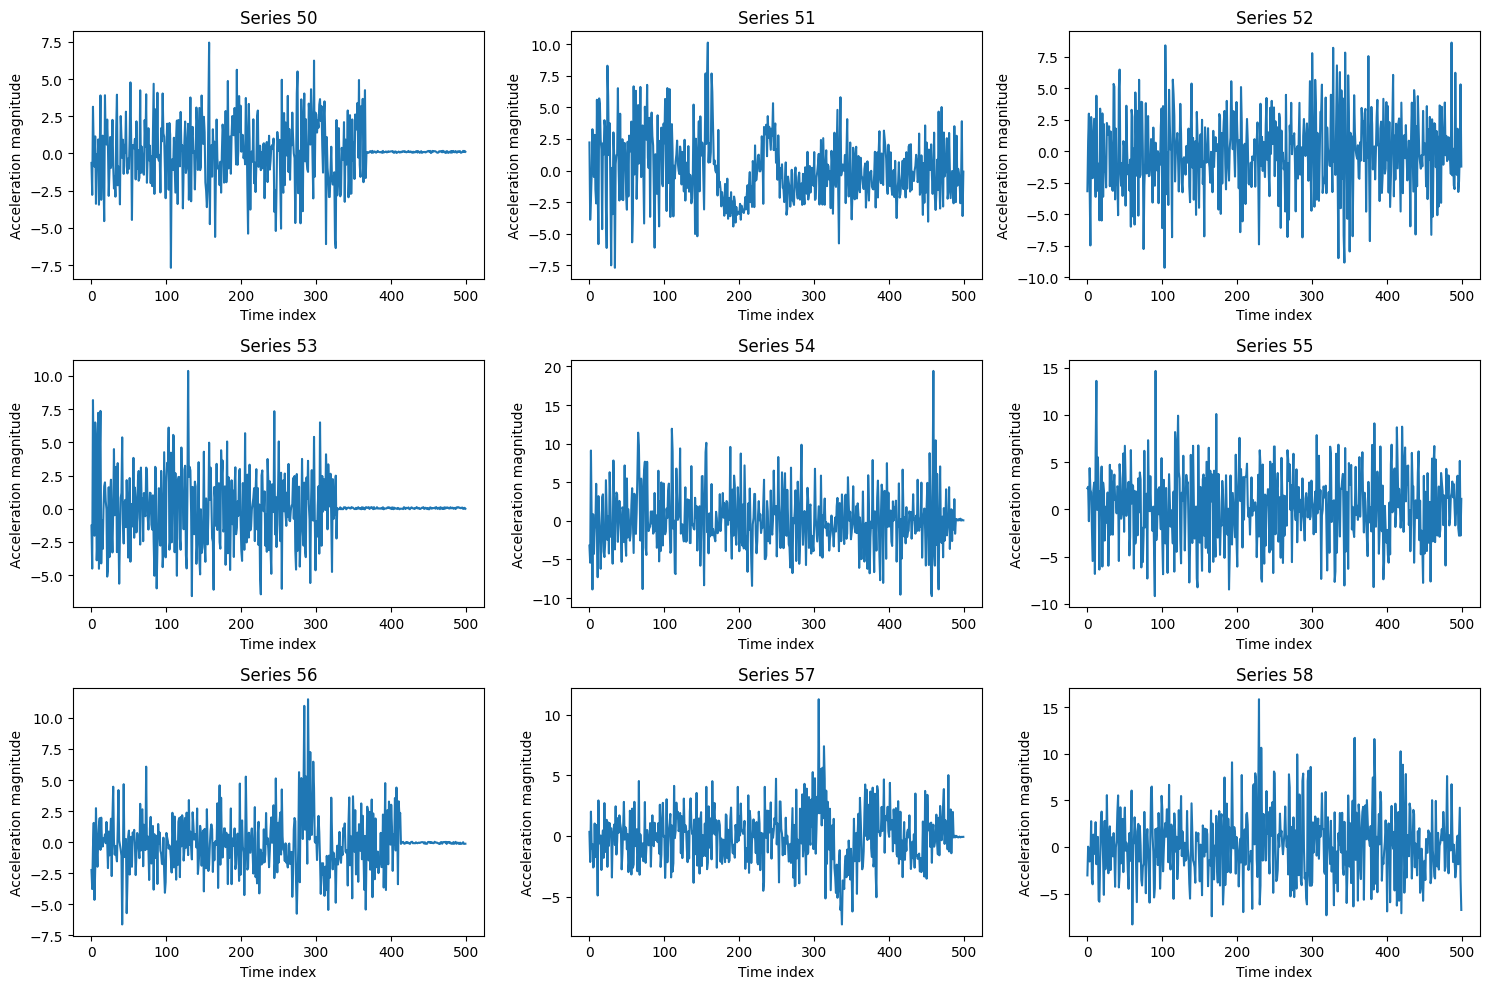

In [4]:
import matplotlib.pyplot as plt
out_idx = []
for i in range(50, 100):
    out_idx.append(i)

sample_idx = out_idx

rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

for ax, i in zip(axes.ravel(), sample_idx):
    ax.plot(X_crop[i])
    ax.set_title(f"Series {i}")
    ax.set_xlabel("Time index")
    ax.set_ylabel("Acceleration magnitude")

plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

n_timestamps_new = 500
feature_names = [f"TimeSeriesData_{i}" for i in range(n_timestamps_new)]

X_crop_df1 = pd.DataFrame(X_crop, columns=feature_names)
Xy_crop_df1 = X_crop_df1.copy()
Xy_crop_df1["ClassLabel"] = y.values   # atau y.to_numpy()

Xy_crop_df1.to_csv("Fix_datasets/AsphaltPavementType_crop400_new.csv", index=False)
Xy_crop_df1


,TimeSeriesData_0,TimeSeriesData_1,TimeSeriesData_2,TimeSeriesData_3,TimeSeriesData_4,TimeSeriesData_5,TimeSeriesData_6,TimeSeriesData_7,TimeSeriesData_8,TimeSeriesData_9,...,TimeSeriesData_491,TimeSeriesData_492,TimeSeriesData_493,TimeSeriesData_494,TimeSeriesData_495,TimeSeriesData_496,TimeSeriesData_497,TimeSeriesData_498,TimeSeriesData_499,ClassLabel
0,-2.876570,1.663488,-4.498386,3.488434,0.395251,-3.587129,0.773357,-0.915250,2.573000,1.361841,...,-1.966742,2.541954,3.979687,0.069312,0.002890,0.019680,0.025300,-0.048612,-0.079107,cobblestone
1,-0.701747,-0.570766,0.566515,-0.218081,1.199675,2.872561,1.940022,-2.274027,1.609701,4.039853,...,-0.048847,-0.035815,0.092891,0.119380,0.028519,0.098225,0.096499,0.056824,-0.032873,cobblestone
2,4.369829,-3.141377,3.529192,2.660682,2.462394,-1.882157,0.104404,0.942166,1.283458,-3.968304,...,0.350013,0.512466,0.347847,0.454590,0.345583,0.356150,0.526843,0.378212,0.405304,cobblestone
3,8.916818,-3.653964,-3.222407,5.952949,-2.532802,-1.536643,2.157628,0.213207,-0.088351,2.634485,...,0.107631,0.035181,0.044870,0.007413,0.052851,0.037498,0.048568,0.098082,-0.041289,cobblestone
4,2.233004,0.050001,-2.284447,-1.813584,2.641198,-1.083767,2.177665,-0.227288,-1.730810,1.752036,...,-1.007197,1.355615,1.069424,-5.078111,5.725278,-1.705188,-1.281729,3.449931,0.033489,cobblestone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,0.880715,-2.346590,-2.329858,2.212091,-1.166301,0.371006,1.442045,-0.190440,-0.507736,-0.681386,...,-1.123848,-3.599494,1.234706,1.238040,-0.097598,1.813744,-2.801330,0.318330,2.075006,dirt
1315,-0.725810,0.307290,-0.665848,0.014449,0.020445,-0.815619,-0.315867,0.660846,-0.794393,0.261320,...,-0.027785,-0.006332,-0.013147,0.007824,0.008854,-0.013834,-0.002892,-0.013829,-0.017042,flexible
1316,6.432972,-0.184155,-4.374001,-0.011607,-1.068614,4.028121,2.998381,-3.004130,2.899988,-0.824554,...,1.337614,1.917584,0.538787,-2.426711,-3.203628,2.804111,-2.418051,-0.364512,3.492263,cobblestone
1317,-0.416838,2.559118,-1.690034,-0.278789,0.573216,0.116075,-0.407203,1.595101,-4.097763,1.875713,...,-0.039176,0.011263,0.009366,0.044120,0.044053,-0.069568,-0.017158,-0.036995,-0.061221,dirt


## Balancing Data

Dataset memiliki distribusi kelas yang tidak seimbang, sehingga dilakukan data balancing pada data training menggunakan metode oversampling. Proses ini bertujuan untuk mengurangi bias model terhadap kelas mayoritas dan meningkatkan performa klasifikasi pada kelas minoritas. Data pengujian tidak ikut dilakukan balancing agar evaluasi model tetap objektif.

In [6]:
from sklearn.model_selection import train_test_split
import numpy as py
from imblearn.over_sampling import RandomOverSampler

X_train, X_test, y_train, y_test = train_test_split(
    X_crop, y,
    test_size=0.2,        
    random_state=42,
    stratify=y              
)

In [7]:
print(y_train.value_counts())


ClassLabel
flexible       402
dirt           393
cobblestone    260
Name: count, dtype: int64


In [8]:

ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

print("Sebelum balancing:")
print(y_train.value_counts())
print("\nSesudah balancing:")
print(y_train_bal.value_counts())

Sebelum balancing:
ClassLabel
flexible       402
dirt           393
cobblestone    260
Name: count, dtype: int64

Sesudah balancing:
ClassLabel
cobblestone    402
flexible       402
dirt           402
Name: count, dtype: int64


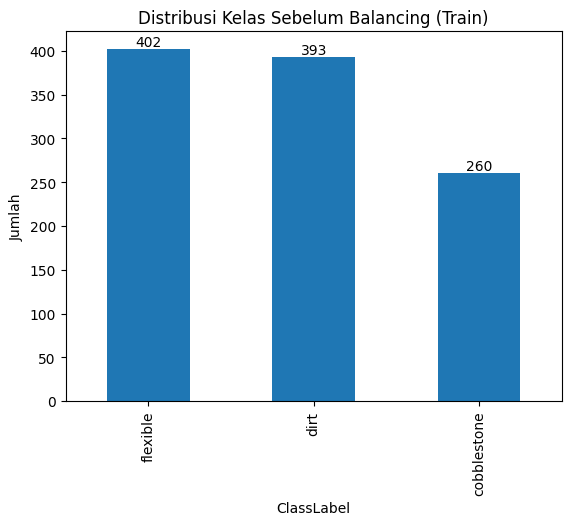

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
y_train.value_counts().plot(kind="bar", ax=ax)
ax.set_title("Distribusi Kelas Sebelum Balancing (Train)")
ax.set_xlabel("ClassLabel")
ax.set_ylabel("Jumlah")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()


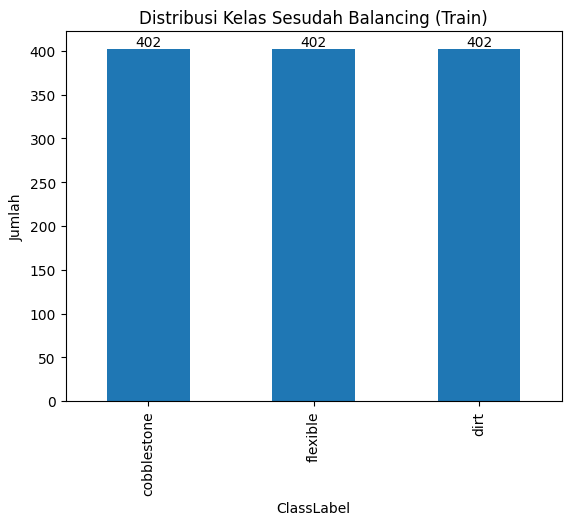

In [10]:
fig, ax = plt.subplots()
y_train_bal.value_counts().plot(kind="bar", ax=ax)
ax.set_title("Distribusi Kelas Sesudah Balancing (Train)")
ax.set_xlabel("ClassLabel")
ax.set_ylabel("Jumlah")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()
